# Model development

In [10]:
from sanity_functions import *

In [11]:
transactions = pd.read_csv('../data/processed/raw_transactions.csv')
transactions.head()

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
0,2024-02-02 21:43:57.697,275.0,0,DAQQ7TS,322.285714,0.0,411.133179,0.000000,0.0,5048.175078,...,0.0000,0.0,7.523910e+08,1.404402e+11,4232421,1.548410e+12,6.384952e+07,0,0,1
1,2024-02-02 20:49:30.476,2805.5,0,CR4K9VY,66.285714,0.0,35289.128889,170.986536,13.0,334646.251337,...,423018.1025,0.0,7.412321e+08,9.651831e+10,8401389,2.947039e+12,2.877422e+07,0,0,1
2,2024-02-02 15:32:12.033,150.0,0,DSSEHKE,284.142857,0.0,1585.621610,0.000000,0.0,10383.890144,...,0.0000,0.0,2.189377e+09,3.328640e+11,18806623,3.802283e+12,1.733248e+08,0,1,0
3,2024-02-02 13:21:08.696,177.0,0,2C2EP9Y,38.857143,0.0,2659.310168,0.000000,46.0,23495.076815,...,5147.0000,0.0,9.638338e+07,4.847552e+09,2114366,6.598435e+10,8.536190e+06,0,0,1
4,2024-02-02 18:32:29.093,259.0,0,C3NYGCP,39.142857,0.0,1663.235351,0.000000,14.0,13035.453581,...,0.0000,1.0,2.997443e+09,5.486961e+11,31893920,5.762067e+12,2.198331e+08,0,0,1


In [12]:
transactions.shape
# (991.965, 91)

(991965, 91)

## Null

In [20]:
import pandas as pd
from scipy import stats


def analyze_nulls_relationship_with_fraud(df):
    """
    Analyze if null values in each column are related to fraud
    by comparing fraud rates and using chi-square test
    """
    results = []

    for column in df.columns:
        if column != 'infraction' and df[column].isnull().any():
            # Calculate fraud rates
            fraud_rate_null = df[df[column].isnull()]['infraction'].mean()
            fraud_rate_not_null = df[df[column].notnull()]['infraction'].mean()

            # Create contingency table for chi-square test
            contingency = pd.crosstab(df[column].isnull(), df['infraction'])

            # Perform chi-square test
            chi2, p_value = stats.chi2_contingency(contingency)[:2]

            # Calculate percentage of nulls
            null_percentage = (df[column].isnull().sum() / len(df)) * 100

            # Calculate relative difference in fraud rates
            if fraud_rate_not_null > 0:
                relative_difference = (fraud_rate_null - fraud_rate_not_null) / fraud_rate_not_null
            else:
                relative_difference = np.inf if fraud_rate_null > 0 else 0

            results.append({
                'Column': column,
                'Null_Percentage': null_percentage,
                'Fraud_Rate_Null': fraud_rate_null,
                'Fraud_Rate_Not_Null': fraud_rate_not_null,
                'Relative_Difference': relative_difference,
                'Chi_Square': chi2,
                'P_Value': p_value,
                'Is_Significant': p_value < 0.05,
                'Conclusion': 'Related to fraud' if p_value < 0.05 else 'Random'
            })

    # Convert to DataFrame and sort by significance
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('P_Value')

    # Format percentages and float values
    results_df['Null_Percentage'] = results_df['Null_Percentage'].round(2)
    results_df['Fraud_Rate_Null'] = results_df['Fraud_Rate_Null'].round(4)
    results_df['Fraud_Rate_Not_Null'] = results_df['Fraud_Rate_Not_Null'].round(4)
    results_df['Relative_Difference'] = results_df['Relative_Difference'].round(2)
    results_df['P_Value'] = results_df['P_Value'].apply(lambda x: f'{x:.2e}')

    return results_df


# Load the data
df = pd.read_csv('../data/processed/raw_transactions.csv')

# Run the analysis
results = analyze_nulls_relationship_with_fraud(df)

# Print results
print("\nNull Values Analysis Results:")
print("\nColumns with significant relationship to fraud (p < 0.05):")
significant = results[results['Is_Significant']]
print(significant[
          ['Column', 'Null_Percentage', 'Fraud_Rate_Null', 'Fraud_Rate_Not_Null', 'Relative_Difference', 'P_Value']])

print("\nColumns with random null distribution (p >= 0.05):")
not_significant = results[~results['Is_Significant']]
print(not_significant[
          ['Column', 'Null_Percentage', 'Fraud_Rate_Null', 'Fraud_Rate_Not_Null', 'Relative_Difference', 'P_Value']])

# Save detailed results
results.to_csv('null_analysis_results.csv', index=False)


Null Values Analysis Results:

Columns with significant relationship to fraud (p < 0.05):
                                               Column  Null_Percentage  \
1                     mc_atm_br_tx_out_count_lifetime             0.38   
3                         mc_billpay_br_count_last_1y             0.39   
5                             mc_pur_br_count_last_1y             0.39   
4               mc_credit_transfer_out_br_sum_last_1y             1.25   
6                        mc_billpay_br_count_last_15d             1.59   
7                      mc_atm_br_tx_out_count_last_1y             0.39   
10           mc_credit_transfer_out_br_count_lifetime             0.38   
9              mc_credit_transfer_in_br_sum_last_180d             1.11   
14             mc_credit_transfer_in_br_sum_last_120d             1.27   
13                           mc_pur_br_count_last_15d             1.59   
11  mc_credit_transfer_out_br_count_sanction_last_30d             0.89   
12           mc_credi

In [21]:
caract_df(transactions)

Nº linhas: 991965
Nº colunas: 91
Nº linhas duplicadas: 0

Nº de vazios*:
	mc_weeks_signup: 11252 - 1.13%
	mc_atm_br_tx_out_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_out_br_sum_last_30d: 27259 - 2.75%
	mc_billpay_br_count_last_1y: 3827 - 0.39%
	mc_credit_transfer_out_br_sum_last_1y: 12432 - 1.25%
	mc_pur_br_count_last_1y: 3827 - 0.39%
	mc_billpay_br_count_last_15d: 15779 - 1.59%
	mc_atm_br_tx_out_count_last_1y: 3827 - 0.39%
	mc_sanction_count_last_2d: 203567 - 20.52%
	mc_credit_transfer_in_br_sum_last_180d: 11013 - 1.11%
	mc_credit_transfer_out_br_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_out_br_count_sanction_last_30d: 8817 - 0.89%
	mc_credit_transfer_out_br_count_last_15d: 15779 - 1.59%
	mc_pur_br_count_last_15d: 15779 - 1.59%
	mc_credit_transfer_in_br_sum_last_120d: 12627 - 1.27%
	mc_pur_br_count_lifetime: 3799 - 0.38%
	mc_credit_transfer_in_br_count_last_30d: 8817 - 0.89%
	mc_credit_transfer_in_br_sum_last_90d: 14011 - 1.41%
	mc_credit_transfer_out_br_count_last_1y: 38

In [22]:
def treat_missing_values(df):
    """
    Comprehensive missing value treatment preserving the signal from null values
    """
    # Create a copy to avoid modifying the original dataframe
    df_treated = df.copy()

    # Store columns to process (excluding target and non-numeric columns)
    columns_to_process = df.select_dtypes(include=['float64', 'int64']).columns
    columns_to_process = [col for col in columns_to_process if
                          not col in ['infraction', 'merchant_id', 'event_created_at']]

    # # Create null indicator features
    # for column in columns_to_process:
    #     if df[column].isnull().any():
    #         # Create missing indicator
    #         df_treated[f'{column}_is_null'] = df[column].isnull().astype(int)

    # Different imputation strategies

    # knn_imputer = KNNImputer(n_neighbors=5)

    # 2. Forward fill for time-dependent features
    df_treated['event_created_at'] = pd.to_datetime(df_treated['event_created_at'])
    df_treated = df_treated.sort_values('event_created_at')

    for column in columns_to_process:
        if df[column].isnull().any():
            # Calculate the fraud rate difference for null vs non-null
            fraud_rate_null = df[df[column].isnull()]['infraction'].mean()
            fraud_rate_non_null = df[df[column].notnull()]['infraction'].mean()
            ratio = fraud_rate_null / fraud_rate_non_null if fraud_rate_non_null > 0 else np.inf

            # Choose imputation strategy based on fraud rate ratio
            if ratio > 10:  # If nulls are much more likely to be fraud
                # Use a special value (e.g., -999) to preserve the signal
                df_treated[column] = df_treated[column].fillna(-999999)
            else:
                df_treated[column] = df_treated[column].fillna(df_treated[column].median())

            # else:
            #    df_treated[column] = pd.DataFrame(
            #         knn_imputer.fit_transform(df_treated[[column]]),
            #         columns=[column],
            #         index=df_treated.index
            #     )

    # # Fill any remaining nulls with median
    # for column in columns_to_process:
    #     if df_treated[column].isnull().any():
    #         df_treated[column] = df_treated[column].fillna(df_treated[column].median())

    return df_treated


# Example usage:
df = pd.read_csv('../data/processed/raw_transactions.csv')

# Get original null counts
null_counts_before = df.isnull().sum()
print("\nNull counts before treatment:")
print(null_counts_before[null_counts_before > 0])

# Apply treatment
df_treated = treat_missing_values(df)

# Get null counts after treatment
null_counts_after = df_treated.isnull().sum()
print("\nNull counts after treatment:")
print(null_counts_after[null_counts_after > 0])

# Print new features created
new_features = [col for col in df_treated.columns if col not in df.columns]
print("\nNew indicator features created:")
print(new_features)


Null counts before treatment:
mc_weeks_signup                                       11252
mc_atm_br_tx_out_count_lifetime                        3799
mc_credit_transfer_out_br_sum_last_30d                27259
mc_billpay_br_count_last_1y                            3827
mc_credit_transfer_out_br_sum_last_1y                 12432
mc_pur_br_count_last_1y                                3827
mc_billpay_br_count_last_15d                          15779
mc_atm_br_tx_out_count_last_1y                         3827
mc_sanction_count_last_2d                            203567
mc_credit_transfer_in_br_sum_last_180d                11013
mc_credit_transfer_out_br_count_lifetime               3799
mc_credit_transfer_out_br_count_sanction_last_30d      8817
mc_credit_transfer_out_br_count_last_15d              15779
mc_pur_br_count_last_15d                              15779
mc_credit_transfer_in_br_sum_last_120d                12627
mc_pur_br_count_lifetime                               3799
mc_credit

In [23]:
df_treated

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mc_tx_cp_dbt_sum_sq_fail_last_14d,mc_merchants_ip_count_dist_shared_last_15d,mcc_sum_succ_1y,mcc_sum_sq_succ_30d,mcc_count_succ_1y,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person
473558,2023-07-01 00:01:02.493914,107.5,0,D62L9GQ,69.714286,0.0,1440.115473,65.510513,19.0,12698.963010,...,0.00,1.0,2.302048e+09,6.907739e+11,20826995,6.583108e+12,2.301642e+08,0,0,1
806288,2023-07-01 00:01:13.949476,138.5,0,ECF6ENP,71.142857,0.0,1733.728697,718.527985,77.0,9497.237914,...,250.75,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
636880,2023-07-01 00:01:32.933130,150.0,0,UK3ZG3M,258.285714,2.0,175.442214,0.000000,0.0,625.039834,...,0.00,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
511561,2023-07-01 00:01:41.744530,135.0,0,CZYH6X7,48.857143,0.0,2615.888201,0.000000,4.0,10640.710971,...,0.00,0.0,2.144144e+09,3.740267e+11,19358946,3.356191e+12,1.778138e+08,0,0,1
687219,2023-07-01 00:01:56.158400,418.0,0,G9PY39Y,190.142857,0.0,1406.257142,0.000000,0.0,9565.032061,...,1028.00,0.0,3.039484e+09,1.524340e+11,101862055,2.233361e+12,2.345546e+08,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204941,2024-05-01 23:58:40.446000,600.0,0,PQ2QDEX,65.285714,0.0,6376.565975,204.061248,18.0,89037.053401,...,1768900.00,0.0,2.020037e+08,6.221600e+10,1213249,6.899038e+11,1.966357e+07,0,0,1
26153,2024-05-01 23:58:45.363000,200.0,0,4V2CR26,253.142857,0.0,5533.079508,0.000000,61.0,41480.860678,...,0.00,0.0,2.217093e+09,3.983409e+11,18281557,4.095064e+12,1.924288e+08,0,0,1
130562,2024-05-01 23:59:49.887000,145.0,0,CCNGDNG,4.142857,0.0,1217.194475,367.828938,4.0,1217.194475,...,0.00,0.0,2.776819e+09,2.310073e+11,93005969,2.290934e+12,2.214253e+08,0,0,1
211337,2024-05-01 23:59:52.112000,150.0,0,CSHCSKM,185.285714,0.0,591.842026,22.174899,12.0,6399.846418,...,0.00,0.0,1.674791e+09,1.370278e+11,51236362,1.531982e+12,1.394113e+08,0,0,1


## Class imbalance

In [8]:
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb


def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Calculate evaluation metrics with model name prefix"""
    metrics = {
        f'{model_name}_Precision': precision_score(y_true, y_pred, zero_division=0),
        f'{model_name}_Recall': recall_score(y_true, y_pred, zero_division=0),
        f'{model_name}_F1-Score': f1_score(y_true, y_pred, zero_division=0),
        f'{model_name}_Avg Precision': average_precision_score(y_true, y_proba),
    }

    # Calculate Precision@100
    y_proba_series = pd.Series(y_proba, index=y_true.index)
    top_100 = y_proba_series.nlargest(100)
    metrics[f'{model_name}_Precision@100'] = y_true.loc[top_100.index].mean()

    return metrics


def train_and_evaluate(X_train, X_test, y_train, y_test, sampler_name, sampler=None):
    """Train and evaluate both models with given sampler"""
    print(f"\nProcessing {sampler_name}...")
    results = {}

    try:
        # Apply sampling only on training data
        if sampler is not None:
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            print(f"Resampled shape: {X_res.shape}, Fraud ratio: {y_res.mean():.4f}")
        else:
            X_res, y_res = X_train, y_train

        class_ratio = len(y_res[y_res == 0]) / len(y_res[y_res == 1])

        # ========== LightGBM ==========
        try:
            lgb_model = lgb.LGBMClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                num_leaves=32,
                scale_pos_weight=class_ratio,
                random_state=42,
                verbose=-1
            )
            lgb_model.fit(X_res, y_res)
            lgb_pred = lgb_model.predict(X_test)
            lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
            results.update(evaluate_model('LGBM', y_test, lgb_pred, lgb_proba))
        except Exception as e:
            print(f"LightGBM Error: {str(e)}")

        # ========== XGBoost ==========
        try:
            xgb_model = xgb.XGBClassifier(
                n_estimators=1000,
                learning_rate=0.01,
                max_depth=5,
                scale_pos_weight=class_ratio,
                eval_metric='aucpr',
                random_state=42
            )
            xgb_model.fit(X_res, y_res)
            xgb_pred = xgb_model.predict(X_test)
            xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
            results.update(evaluate_model('XGB', y_test, xgb_pred, xgb_proba))
        except Exception as e:
            print(f"XGBoost Error: {str(e)}")

        return results

    except Exception as e:
        print(f"General Error: {str(e)}")
        return {k: np.nan for k in [
            'LGBM_Precision', 'LGBM_Recall', 'LGBM_F1-Score', 'LGBM_Avg Precision', 'LGBM_Precision@100',
            'XGB_Precision', 'XGB_Recall', 'XGB_F1-Score', 'XGB_Avg Precision', 'XGB_Precision@100'
        ]}


def main():
    """Main execution flow"""
    # Load and prepare data
    # df = pd.read_parquet('sumup_cas.parquet').sort_values('event_created_at')
    df = df_treated.sort_values('event_created_at').copy()

    # Feature selection
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']

    # Time-based split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,
        # shuffle=False
    )

    # Define samplers with 20% fraud target
    samplers = {
        'No Sampling': None,
        'Random Under': RandomUnderSampler(sampling_strategy=0.25, random_state=42),
        'SMOTE': SMOTE(sampling_strategy=0.25, random_state=42),
        # 'ADASYN': ADASYN(sampling_strategy=0.25, random_state=42),
        # 'SMOTE-Tomek': SMOTETomek(sampling_strategy=0.25, random_state=42),
        # 'SMOTE-ENN': SMOTEENN(sampling_strategy=0.25, random_state=42)
    }

    # Evaluate all samplers
    results = {}
    for name, sampler in samplers.items():
        results[name] = train_and_evaluate(X_train, X_test, y_train, y_test, name, sampler)

    # Save and display results
    results_df = pd.DataFrame(results).T
    results_df.to_csv('sampling_results.csv', float_format='%.4f')

    print("\nFinal Results:")
    print(results_df)

    return results_df


if __name__ == "__main__":
    main()


Processing No Sampling...


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:28:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Processing Random Under...
Resampled shape: (19990, 88), Fraud ratio: 0.2000


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:29:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Processing SMOTE...
Resampled shape: (986967, 88), Fraud ratio: 0.2000


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [18:31:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Final Results:
              LGBM_Precision  LGBM_Recall  LGBM_F1-Score  LGBM_Avg Precision  \
No Sampling         0.163205     0.924827       0.277448            0.477344   
Random Under        0.140550     0.929773       0.244188            0.457074   
SMOTE               0.212440     0.878338       0.342131            0.483515   

              LGBM_Precision@100  XGB_Precision  XGB_Recall  XGB_F1-Score  \
No Sampling                 0.79       0.137287    0.922849      0.239016   
Random Under                0.77       0.126603    0.927794      0.222803   
SMOTE                       0.75       0.172785    0.889219      0.289347   

              XGB_Avg Precision  XGB_Precision@100  
No Sampling            0.444206               0.75  
Random Under           0.434317               0.76  
SMOTE                  0.450041               0.76  


## Feature engineering

In [24]:
# 1. Create weekend flag:
#    Weekday numbers: Monday=0, Tuesday=1, ... Sunday=6.
#    Set flag = 1 for Saturday (5) or Sunday (6), else 0.
df_treated['is_weekend'] = df_treated['event_created_at'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# 2. Create night flag:
#    We define "day" as from 6:00 (6 AM) to 18:00 (6 PM). Transactions outside that range are considered "night".
df_treated['is_night'] = df_treated['event_created_at'].dt.hour.apply(lambda x: 1 if (x < 6 or x >= 18) else 0)

# 3. Extract additional temporal features: month, day, and hour.
df_treated['month'] = df_treated['event_created_at'].dt.month
df_treated['day'] = df_treated['event_created_at'].dt.day
df_treated['hour'] = df_treated['event_created_at'].dt.hour

df_treated.to_csv('../data/processed/df_treated.csv', index=False)

df_treated

,event_created_at,amount,infraction,merchant_id,mc_weeks_signup,mc_atm_br_tx_out_count_lifetime,mc_credit_transfer_out_br_sum_last_30d,mc_billpay_br_sum_last_15d,mc_billpay_br_count_last_1y,mc_credit_transfer_out_br_sum_last_1y,...,mcc_sum_sq_succ_1y,mcc_sum_succ_30d,is_legal_entity,is_mei,is_person,is_weekend,is_night,month,day,hour
473558,2023-07-01 00:01:02.493914,107.5,0,D62L9GQ,69.714286,0.0,1440.115473,65.510513,19.0,12698.963010,...,6.583108e+12,2.301642e+08,0,0,1,1,1,7,1,0
806288,2023-07-01 00:01:13.949476,138.5,0,ECF6ENP,71.142857,0.0,1733.728697,718.527985,77.0,9497.237914,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
636880,2023-07-01 00:01:32.933130,150.0,0,UK3ZG3M,258.285714,2.0,175.442214,0.000000,0.0,625.039834,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
511561,2023-07-01 00:01:41.744530,135.0,0,CZYH6X7,48.857143,0.0,2615.888201,0.000000,4.0,10640.710971,...,3.356191e+12,1.778138e+08,0,0,1,1,1,7,1,0
687219,2023-07-01 00:01:56.158400,418.0,0,G9PY39Y,190.142857,0.0,1406.257142,0.000000,0.0,9565.032061,...,2.233361e+12,2.345546e+08,0,0,1,1,1,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204941,2024-05-01 23:58:40.446000,600.0,0,PQ2QDEX,65.285714,0.0,6376.565975,204.061248,18.0,89037.053401,...,6.899038e+11,1.966357e+07,0,0,1,0,1,5,1,23
26153,2024-05-01 23:58:45.363000,200.0,0,4V2CR26,253.142857,0.0,5533.079508,0.000000,61.0,41480.860678,...,4.095064e+12,1.924288e+08,0,0,1,0,1,5,1,23
130562,2024-05-01 23:59:49.887000,145.0,0,CCNGDNG,4.142857,0.0,1217.194475,367.828938,4.0,1217.194475,...,2.290934e+12,2.214253e+08,0,0,1,0,1,5,1,23
211337,2024-05-01 23:59:52.112000,150.0,0,CSHCSKM,185.285714,0.0,591.842026,22.174899,12.0,6399.846418,...,1.531982e+12,1.394113e+08,0,0,1,0,1,5,1,23


In [13]:
df_treated = pd.read_csv('../data/processed/df_treated.csv')

## Classification


=== Training DecisionTree ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Training RandomForest ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits

=== Training XGBoost ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py:158: UserWarning: [14:28:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Training AdaBoost ===
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Final Model Comparison:
                Recall Precision@100 Avg Precision   ROC_AUC  \
XGBoost       0.903626           0.7      0.451091  0.973077   
RandomForest  0.900763          0.91      0.553442  0.976406   
DecisionTree  0.873092          0.03      0.130034   0.92608   
AdaBoost      0.848282          0.64       0.35088  0.964991   

                                                    Best Params  
XGBoost       {'model__learning_rate': 0.1, 'model__max_dept...  
RandomForest  {'model__max_depth': 50, 'model__n_estimators'...  
DecisionTree  {'model__max_depth': 10, 'model__min_samples_s...  
AdaBoost      {'model__learning_rate': 0.25, 'model__n_estim...  


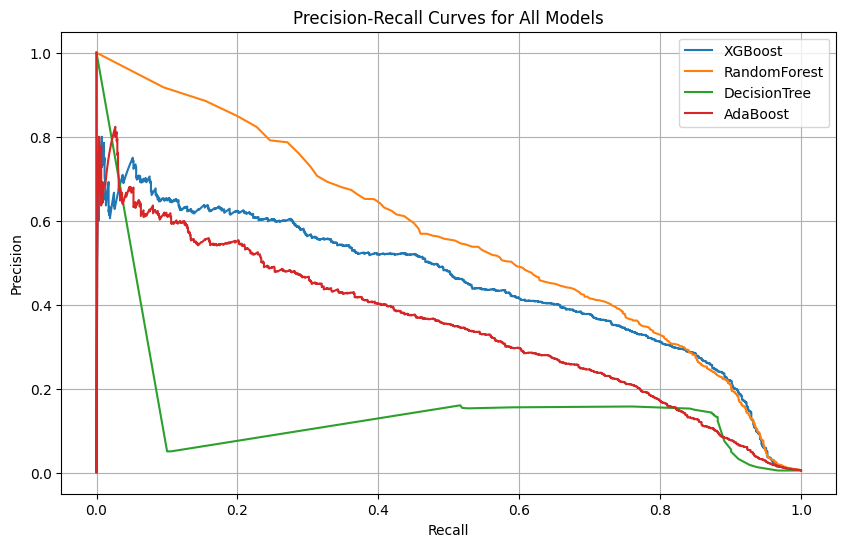


Best Model: XGBoost with Recall 0.9036


In [14]:
from sklearn.model_selection import StratifiedKFold
from joblib import parallel_backend
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_recall_curve

# 1. Load and prepare data
# df = pd.read_parquet('sumup_cas.parquet').sort_values('event_created_at')
# df = df_treated.copy()
df = pd.read_csv('../data/processed/df_treated.csv')
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
y = df['infraction']

# Time-based split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

# 2. Define model collection with parameter grids
models = {
    'DecisionTree': (
        DecisionTreeClassifier(),
        {'model__max_depth': [5, 10, 20, 50],
         'model__min_samples_split': [2, 5]}
    ),
    'RandomForest': (
        RandomForestClassifier(),
        {'model__n_estimators': [20, 100, 200, 500],
         'model__max_depth': [5, 10, 20, 50]}
    ),
    # 'SVM': (
    #     SVC(probability=True),
    #     {'model__C': [0.1, 1, 10],
    #      'model__kernel': ['linear', 'rbf', 'poly']}
    # ),
    'XGBoost': (
        XGBClassifier(eval_metric='aucpr'),
        {'model__learning_rate': [0.01, 0.1, 0.25],
         'model__max_depth': [5, 10, 20, 50],
         'model__n_estimators': [20, 50, 100, 200, 500]}
    ),
    'AdaBoost': (
        AdaBoostClassifier(),
        {'model__n_estimators': [20, 50, 100, 200, 500],
         'model__learning_rate': [0.01, 0.1, 0.25]}
    ),
    # 'LightGBM': (
    #     lgb.LGBMClassifier(),
    #     {'model__num_leaves': [16, 32],
    #      'model__learning_rate': [0.01, 0.1, 0.25]}
    # ),
    # 'MLP': (
    #     MLPClassifier(early_stopping=True),
    #     {'model__hidden_layer_sizes': [(50,), (100,), (150,)],
    #      'model__alpha': [0.0001, 0.001, 0.002]}
    # )
}

# 3. Train and validate models
results = {}
best_estimators = {}

for model_name, (estimator, param_grid) in models.items():
    try:
        print(f"\n=== Training {model_name} ===")

        # Create pipeline with RUS and model
        pipeline = Pipeline([
            ('sampler', RandomUnderSampler(sampling_strategy=0.25, random_state=42)),
            ('model', estimator)
        ])

        # Grid search with recall optimization
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring='recall',
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            n_jobs=-1,
            verbose=1
        )

        # Use multiprocessing backend for better memory management
        with parallel_backend('multiprocessing'):
            grid.fit(X_train, y_train)

        # Store best model
        best_estimators[model_name] = grid.best_estimator_

        # Validate on test set
        y_pred = grid.best_estimator_.predict(X_test)
        y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

        # Calculate metrics
        precision, recall, _ = precision_recall_curve(y_test, y_proba)

        results[model_name] = {
            'Best Params': grid.best_params_,
            'Recall': recall_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_proba),
            'Avg Precision': average_precision_score(y_test, y_proba),
            'Precision@100': y_test[pd.Series(y_proba, index=y_test.index).nlargest(100).index].mean(),
            'Confusion_Matrix': confusion_matrix(y_test, y_pred).tolist(),
            'PR_Curve': {
                'Precision': precision.tolist(),
                'Recall': recall.tolist()
            }
        }

    except Exception as e:
        print(f"Error with {model_name}: {str(e)}")
        results[model_name] = 'Failed'

# 4. Save and display results
results_df = pd.DataFrame(results).T.sort_values('Recall', ascending=False)
results_df.to_csv('model_selection_results.csv', float_format='%.4f')

print("\nFinal Model Comparison:")
print(results_df[['Recall', 'Precision@100', 'Avg Precision', 'ROC_AUC', 'Best Params']])

# Plot PR curves for all models
plt.figure(figsize=(10, 6))
for model_name in results_df.index:
    if isinstance(results[model_name], dict):  # Check if model training succeeded
        pr_curve = results[model_name]['PR_Curve']
        plt.plot(pr_curve['Recall'], pr_curve['Precision'], label=f'{model_name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend()
plt.grid(True)
plt.show()

# 5. Select best model based on validation recall
best_model_name = results_df.index[0]
best_model = best_estimators[best_model_name]
print(f"\nBest Model: {best_model_name} with Recall {results_df.iloc[0].Recall:.4f}")

High recall is beneficial as the false positives will be discarded anyway by the investigators, within the limit of their bandwidth.

In [17]:
best_model

Pipeline(steps=[('sampler',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.25)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='aucpr',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [21]:
import yaml
from datetime import datetime
import os


def save_model_artifacts(best_model, results_df, X_train, feature_names=None, output_dir='../model/supervised'):
    """
    Save all model artifacts including the model itself, configurations, and metadata.

    Args:
        best_model: The trained model (Pipeline containing sampler and XGBoost)
        results_df: DataFrame containing model comparison results
        X_train: Training data used (for feature names)
        feature_names: List of feature names (optional)
        output_dir: Directory to save artifacts
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # 1. Save the model
    model_path = os.path.join(output_dir, f'xgboost_model_{timestamp}.pkl')
    joblib.dump(best_model, model_path)

    # 2. Extract XGBoost model from pipeline
    xgb_model = best_model.named_steps['model']

    # 3. Save model configuration
    model_config = {
        'model_type': 'XGBoost',
        'timestamp': timestamp,
        'feature_names': feature_names if feature_names else X_train.columns.tolist(),
        'model_parameters': xgb_model.get_params(),
        'feature_importance': {
            name: float(score)
            for name, score in zip(
                X_train.columns,
                xgb_model.feature_importances_
            )
        },
        'performance_metrics': {
            metric: float(value) if isinstance(value, (np.float64, np.float32)) else value
            for metric, value in results_df.iloc[0].items()
            if metric != 'Best Params' and metric != 'Confusion_Matrix' and metric != 'PR_Curve'
        },
        'preprocessing': {
            'sampling_strategy': best_model.named_steps['sampler'].get_params()['sampling_strategy'],
            'random_state': best_model.named_steps['sampler'].get_params()['random_state']
        }
    }

    # Save as YAML for human readability
    config_path = os.path.join(output_dir, f'model_config_{timestamp}.yaml')
    with open(config_path, 'w') as f:
        yaml.dump(model_config, f, default_flow_style=False)

    # 4. Save feature importance plot
    plt.figure(figsize=(10, 6))
    feature_importance = pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True)

    feature_importance.plot(kind='barh')
    plt.title('XGBoost Feature Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'feature_importance_{timestamp}.png'))
    plt.close()

    # 5. Generate model card
    model_card = f"""
# XGBoost Model Card

## Model Information
- Model Type: XGBoost Classifier
- Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- Model Version: {timestamp}

## Performance Metrics
- Recall: {results_df.iloc[0]['Recall']:.4f}
- Precision: {results_df.iloc[0]['Precision']:.4f}
- F1-Score: {results_df.iloc[0]['F1-Score']:.4f}
- ROC AUC: {results_df.iloc[0]['ROC_AUC']:.4f}
- Average Precision: {results_df.iloc[0]['Avg Precision']:.4f}
- Precision@100: {results_df.iloc[0]['Precision@100']:.4f}

## Model Configuration
- Sampling Strategy: {best_model.named_steps['sampler'].get_params()['sampling_strategy']}
- Random State: {best_model.named_steps['sampler'].get_params()['random_state']}

## Usage
```python
import joblib

# Load the model
model = joblib.load('{model_path}')

# Make predictions
predictions = model.predict(X)
probabilities = model.predict_proba(X)
```

## Files
- Model: {os.path.basename(model_path)}
- Config: {os.path.basename(config_path)}
- Feature Importance Plot: feature_importance_{timestamp}.png

## Notes
- Model includes preprocessing pipeline with RandomUnderSampler
- Feature importance plot available in artifacts directory
- Full configuration details in YAML file
    """

    # Save model card
    with open(os.path.join(output_dir, f'model_card_{timestamp}.md'), 'w') as f:
        f.write(model_card)

    print(f"\nModel artifacts saved in directory: {output_dir}")
    print(f"Model file: {os.path.basename(model_path)}")
    print(f"Config file: {os.path.basename(config_path)}")
    print(f"Model card: model_card_{timestamp}.md")

    return {
        'model_path': model_path,
        'config_path': config_path,
        'timestamp': timestamp
    }


# Function to load the model and make predictions
def load_model_and_predict(model_path, X):
    """
    Load the saved model and make predictions.

    Args:
        model_path: Path to the saved model file
        X: Features to predict on

    Returns:
        Tuple of (predictions, probabilities)
    """
    model = joblib.load(model_path)
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]
    return predictions, probabilities


# Save all model artifacts
artifacts = save_model_artifacts(
    best_model=best_model,
    results_df=results_df,
    X_train=X_train
)

# Example of loading and using the model
# new_predictions, new_probabilities = load_model_and_predict(artifacts['model_path'], X_test)


Model artifacts saved in directory: ../model/supervised
Model file: xgboost_model_20250212_144931.pkl
Config file: model_config_20250212_144931.yaml
Model card: model_card_20250212_144931.md


C:\Users\gabri\AppData\Local\Temp\ipykernel_14416\3424760268.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['event_created_at'] = pd.to_datetime(test_df['event_created_at'])



Test set spans 306 days


C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


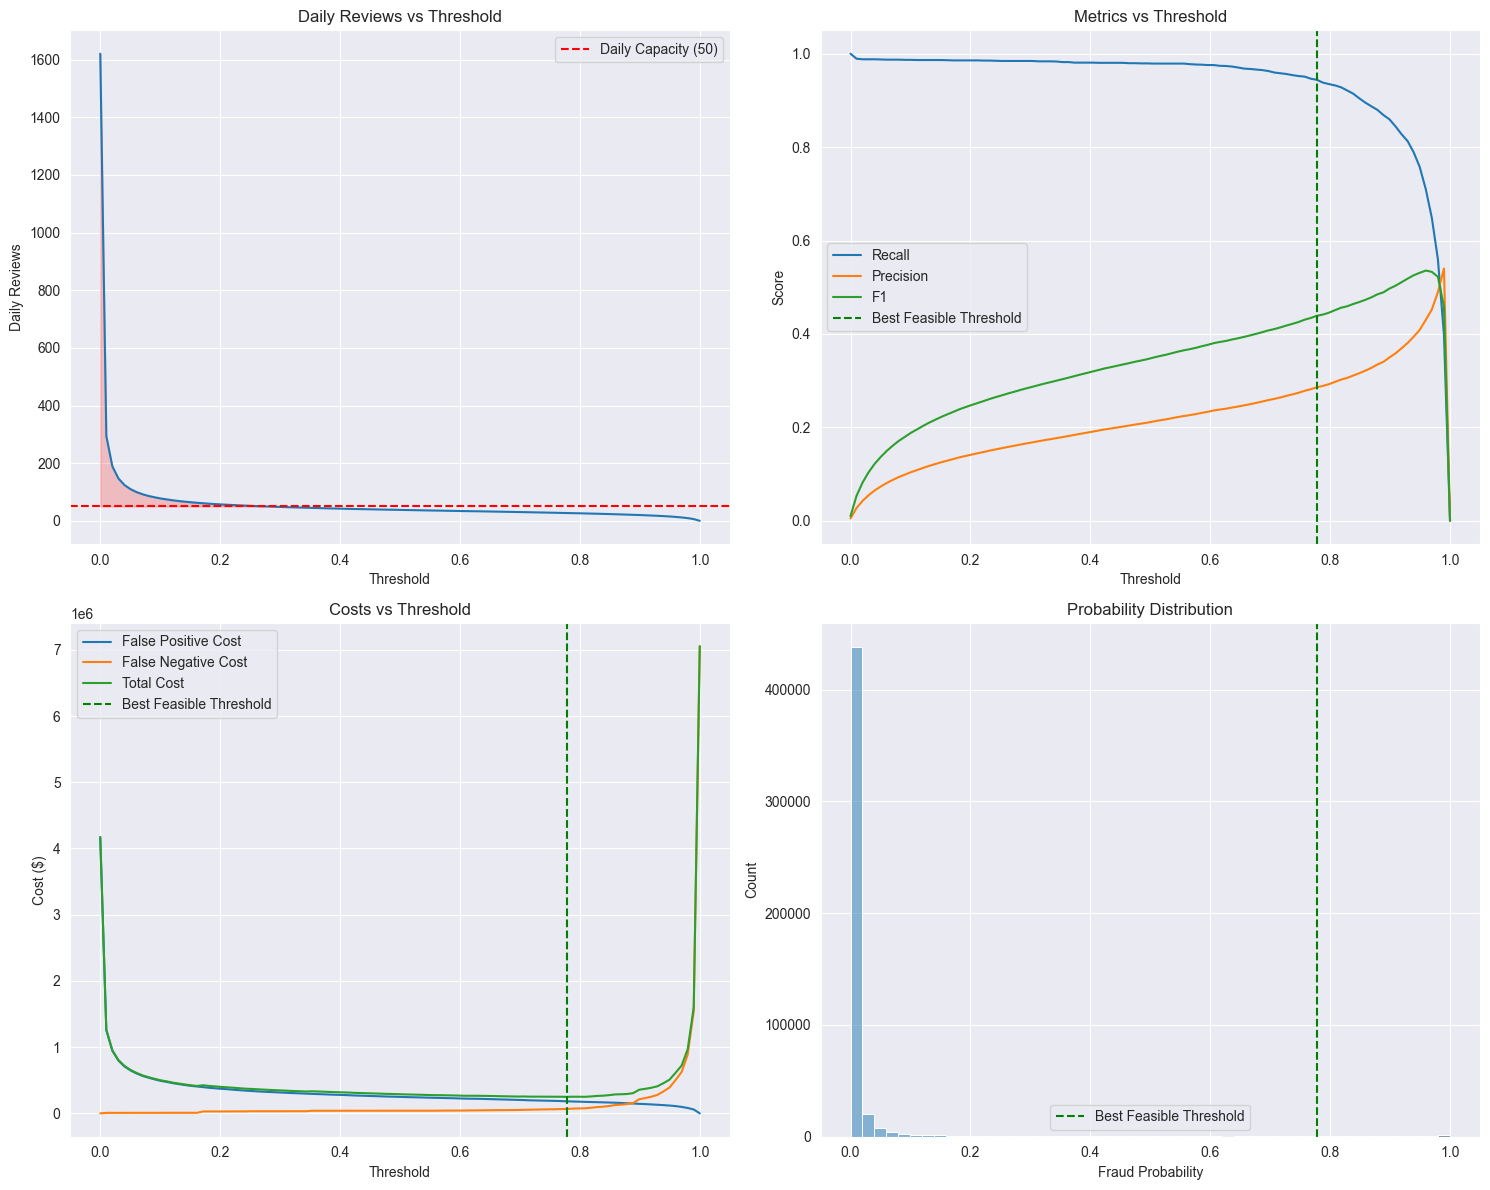


Best Feasible Threshold Analysis:
Threshold: 0.7778
Daily Reviews: 27.0 (Within Capacity)
Recall: 0.9441
Precision: 0.2859
F1-Score: 0.4389
Total Reviews: 8272
Caught Frauds: 2365
Missed Frauds: 140
False Positive Cost: $182,386.22
False Negative Cost: $66,725.02
Total Cost: $249,111.24
Monthly Cost: $24,422.67

Threshold Analysis at Different Levels:

Threshold 0.5:
Daily Reviews: 39.8 (Within Capacity)
Recall: 0.9804
Precision: 0.2018
Total Cost: $301,084.98
Monthly Cost: $29,518.14

Threshold 0.6:
Daily Reviews: 35.7 (Within Capacity)
Recall: 0.9788
Precision: 0.2242
Total Cost: $275,623.47
Monthly Cost: $27,021.91

Threshold 0.7:
Daily Reviews: 32.1 (Within Capacity)
Recall: 0.9681
Precision: 0.2471
Total Cost: $261,628.52
Monthly Cost: $25,649.86

Threshold 0.8:
Daily Reviews: 28.0 (Within Capacity)
Recall: 0.9509
Precision: 0.2783
Total Cost: $251,041.65
Monthly Cost: $24,611.93

Threshold 0.9:
Daily Reviews: 22.8 (Within Capacity)
Recall: 0.8954
Precision: 0.3214
Total Cost: $2

IndexError: single positional indexer is out-of-bounds

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import joblib
from sklearn.metrics import recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_xgboost_thresholds(df, max_daily_reviews=100, n_thresholds=100, fp_weight=0.1):
    """
    Train XGBoost and analyze different probability thresholds with daily review constraint

    Parameters:
    - df: DataFrame with the data
    - max_daily_reviews: Maximum number of reviews that can be handled per day
    - n_thresholds: Number of threshold points to analyze
    - fp_weight: float between 0 and 1 for the cost of false positive transacrions
    """
    # Prepare features
    df = df.copy()
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.5,
        # random_state=42,
        stratify=y
    )

    # Get test set dates to calculate number of days
    test_df = df.iloc[y_test.index]
    test_df['event_created_at'] = pd.to_datetime(test_df['event_created_at'])
    n_days = test_df['event_created_at'].dt.strftime('%Y%m%d').nunique()
    print(f"\nTest set spans {n_days} days")

    # Load pre-trained model
    model = joblib.load('../model/supervised/xgboost_model_20250212_144931.pkl')
    probas = model.predict_proba(X_test)[:, 1]

    # Analyze different thresholds
    thresholds = np.linspace(0, 1, n_thresholds)
    results = []

    for threshold in thresholds:
        # Get predictions for this threshold
        predictions = (probas > threshold).astype(int)

        # Calculate metrics
        recall = recall_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)
        amount = X_test['amount']

        # Calculate costs using transaction amounts
        fp_mask = (predictions == 1) & (y_test == 0)
        fp_cost = amount[fp_mask].sum() * fp_weight

        fn_mask = (predictions == 0) & (y_test == 1)
        fn_cost = amount[fn_mask].sum()

        total_cost = fp_cost + fn_cost

        # Count transactions
        n_reviews = sum(predictions)
        daily_reviews = n_reviews / n_days
        monthly_cost = (total_cost / n_days) * 30
        exceeds_capacity = daily_reviews > max_daily_reviews

        n_caught_frauds = sum((predictions == 1) & (y_test == 1))
        n_missed_frauds = sum((predictions == 0) & (y_test == 1))

        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'n_reviews': n_reviews,
            'daily_reviews': daily_reviews,
            'exceeds_capacity': exceeds_capacity,
            'n_caught_frauds': n_caught_frauds,
            'n_missed_frauds': n_missed_frauds,
            'fp_cost': fp_cost,
            'fn_cost': fn_cost,
            'total_cost': total_cost,
            'monthly_cost': monthly_cost
        })

    results_df = pd.DataFrame(results)

    # Find optimal thresholds considering capacity constraint
    feasible_results = results_df[~results_df['exceeds_capacity']]

    if len(feasible_results) > 0:
        best_cost_idx = feasible_results['total_cost'].idxmin()
        best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']
    else:
        print("\nWarning: No threshold meets the daily review capacity constraint!")
        best_cost_idx = results_df['total_cost'].idxmin()
        best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']

    # Plot results
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Daily Reviews vs Threshold with Capacity
    ax1.plot(results_df['threshold'], results_df['daily_reviews'])
    ax1.axhline(y=max_daily_reviews, color='r', linestyle='--',
                label=f'Daily Capacity ({max_daily_reviews})')
    ax1.fill_between(results_df['threshold'],
                     results_df['daily_reviews'],
                     max_daily_reviews,
                     where=(results_df['daily_reviews'] > max_daily_reviews),
                     color='red', alpha=0.2)
    ax1.set_title('Daily Reviews vs Threshold')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Daily Reviews')
    ax1.legend()

    # Plot 2: Metrics vs Threshold
    ax2.plot(results_df['threshold'], results_df['recall'], label='Recall')
    ax2.plot(results_df['threshold'], results_df['precision'], label='Precision')
    ax2.plot(results_df['threshold'], results_df['f1_score'], label='F1')
    ax2.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax2.set_title('Metrics vs Threshold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Score')
    ax2.legend()

    # Plot 3: Costs vs Threshold
    ax3.plot(results_df['threshold'], results_df['fp_cost'],
             label='False Positive Cost')
    ax3.plot(results_df['threshold'], results_df['fn_cost'],
             label='False Negative Cost')
    ax3.plot(results_df['threshold'], results_df['total_cost'],
             label='Total Cost')
    ax3.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax3.set_title('Costs vs Threshold')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Cost ($)')
    ax3.legend()

    # Plot 4: Probability Distribution
    sns.histplot(data=pd.DataFrame({
        'Fraud Probability': probas,
        'Type': ['Fraud' if y == 1 else 'Normal' for y in y_test]
    }), x='Fraud Probability', hue='Type', bins=50, ax=ax4)
    ax4.axvline(best_cost_threshold, color='g', linestyle='--',
                label='Best Feasible Threshold')
    ax4.set_title('Probability Distribution')
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # Print summary for best feasible threshold
    print("\nBest Feasible Threshold Analysis:")
    best_results = results_df.iloc[best_cost_idx]
    print(f"Threshold: {best_results['threshold']:.4f}")
    print(f"Daily Reviews: {best_results['daily_reviews']:.1f} "
          f"({'EXCEEDS' if best_results['exceeds_capacity'] else 'Within'} Capacity)")
    print(f"Recall: {best_results['recall']:.4f}")
    print(f"Precision: {best_results['precision']:.4f}")
    print(f"F1-Score: {best_results['f1_score']:.4f}")
    print(f"Total Reviews: {best_results['n_reviews']}")
    print(f"Caught Frauds: {best_results['n_caught_frauds']}")
    print(f"Missed Frauds: {best_results['n_missed_frauds']}")
    print(f"False Positive Cost: ${best_results['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${best_results['fn_cost']:,.2f}")
    print(f"Total Cost: ${best_results['total_cost']:,.2f}")
    print(f"Monthly Cost: ${best_results['monthly_cost']:,.2f}")

    # Print threshold recommendations
    print("\nThreshold Analysis at Different Levels:")
    for threshold in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
        thresh_data = results_df[results_df['threshold'].round(1) == threshold].iloc[0]
        capacity_status = "EXCEEDS CAPACITY" if thresh_data['exceeds_capacity'] else "Within Capacity"
        print(f"\nThreshold {threshold}:")
        print(f"Daily Reviews: {thresh_data['daily_reviews']:.1f} ({capacity_status})")
        print(f"Recall: {thresh_data['recall']:.4f}")
        print(f"Precision: {thresh_data['precision']:.4f}")
        print(f"Total Cost: ${thresh_data['total_cost']:,.2f}")
        print(f"Monthly Cost: ${thresh_data['monthly_cost']:,.2f}")

    return model, results_df, probas


# Run the analysis
xgb_model, results_df, probas = analyze_xgboost_thresholds(
    df_treated,
    max_daily_reviews=50, fp_weight = 0.025  # Adjust based on your team's capacity
)